# Laboratorio 8 — Validación cruzada y ajuste de hiperparámetros

**Objetivo:** entrenar modelos supervisados de clasificación usando `Pipeline`, `StratifiedKFold`, `GridSearchCV` y `RandomizedSearchCV`.

> Los datasets se entregan completos. El corte train/test se realiza dentro del notebook para evitar fuga de información.

In [1]:
# Imports + detección automática de la carpeta de datasets
import os, glob, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, precision_score, recall_score, f1_score, roc_auc_score)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Ajustar esta ruta en Colab si subes los archivos manualmente.
CANDIDATE_DIRS = ["../datasets/lab08", "./datasets/lab08", "./datasets", "../datasets", "/content/datasets", "/content"]
DATASET_DIR = next((d for d in CANDIDATE_DIRS if os.path.isdir(d) and len(glob.glob(os.path.join(d, "*.csv"))) > 0), None)
if DATASET_DIR is None:
    raise FileNotFoundError("No se encontraron CSV. Sube la carpeta datasets o ajusta DATASET_DIR.")
print("DATASET_DIR =", DATASET_DIR)
print("Archivos:", [os.path.basename(p) for p in glob.glob(os.path.join(DATASET_DIR, "*.csv"))])

DATASET_DIR = ../datasets/lab08
Archivos: ['dataset_seccion_3_fraude_transaccional.csv', 'dataset_seccion_2_mantenimiento_maquinas.csv', 'dataset_seccion_1_riesgo_academico.csv', 'dataset_seccion_4_calidad_aire.csv']


In [2]:
# Funciones reutilizables: cargar CSV, preprocesar, evaluar, separar X/y
def load_csv(name):
    path = os.path.join(DATASET_DIR, name)
    if not os.path.exists(path):
        matches = glob.glob(os.path.join(DATASET_DIR, "*" + name + "*"))
        if matches:
            path = matches[0]
        else:
            raise FileNotFoundError(path)
    return pd.read_csv(path)

def build_preprocessor(X):
    numeric_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
    categorical_cols = X.select_dtypes(exclude=["number", "bool"]).columns.tolist()
    numeric_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    categorical_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])
    return ColumnTransformer(transformers=[
        ("num", numeric_pipe, numeric_cols),
        ("cat", categorical_pipe, categorical_cols)
    ])

def evaluate_model(model, X_test, y_test, label="modelo"):
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else pred
    out = {
        "modelo": label,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba)
    }
    print(pd.Series(out).to_string())
    print("\nReporte de clasificación")
    print(classification_report(y_test, pred, zero_division=0))
    ConfusionMatrixDisplay.from_predictions(y_test, pred)
    plt.title(f"Matriz de confusión — {label}")
    plt.show()
    return out, pred, proba

def split_xy(df, target_col, drop_id=True):
    y = df[target_col].astype(int)
    X = df.drop(columns=[target_col])
    if drop_id:
        id_like = [c for c in X.columns if c.lower().startswith("id_")]
        X = X.drop(columns=id_like)
    return X, y

## Sección 1 — Baseline con holdout estratificado
Dataset: riesgo académico.

modelo       LogisticRegression
accuracy               0.866667
precision              0.661871
recall                 0.910891
f1                     0.766667
roc_auc                0.958441

Reporte de clasificación
              precision    recall  f1-score   support

           0       0.97      0.85      0.91       319
           1       0.66      0.91      0.77       101

    accuracy                           0.87       420
   macro avg       0.81      0.88      0.84       420
weighted avg       0.89      0.87      0.87       420



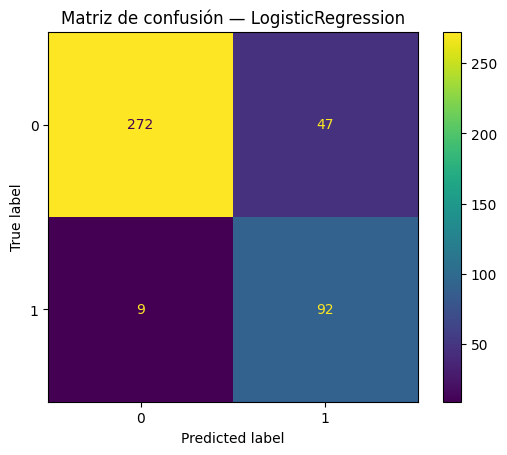

modelo       RandomForest
accuracy         0.835714
precision        0.847826
recall           0.386139
f1               0.530612
roc_auc          0.915904

Reporte de clasificación
              precision    recall  f1-score   support

           0       0.83      0.98      0.90       319
           1       0.85      0.39      0.53       101

    accuracy                           0.84       420
   macro avg       0.84      0.68      0.72       420
weighted avg       0.84      0.84      0.81       420



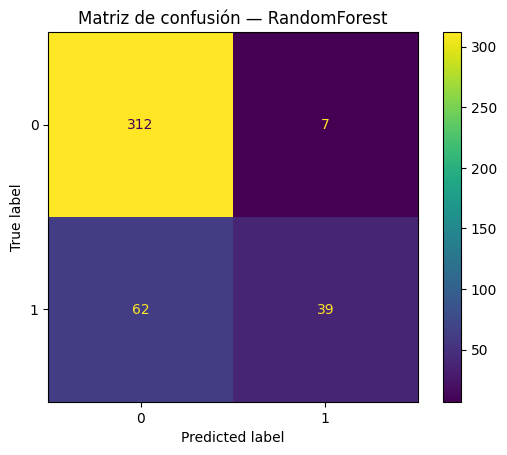

,modelo,accuracy,precision,recall,f1,roc_auc
0,LogisticRegression,0.866667,0.661871,0.910891,0.766667,0.958441
1,RandomForest,0.835714,0.847826,0.386139,0.530612,0.915904


In [3]:
# Sección 1: baseline con holdout estratificado (LogReg vs RF)
df1 = load_csv("dataset_seccion_1_riesgo_academico.csv")
X, y = split_xy(df1, "target_riesgo_academico")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(n_estimators=80, random_state=RANDOM_STATE, class_weight="balanced")
}

baseline_results = []
for name, clf in models.items():
    pipe = Pipeline(steps=[("prep", build_preprocessor(X_train)), ("clf", clf)])
    pipe.fit(X_train, y_train)
    metrics, _, _ = evaluate_model(pipe, X_test, y_test, name)
    baseline_results.append(metrics)

pd.DataFrame(baseline_results)

## Sección 2 — StratifiedKFold
Dataset: mantenimiento predictivo. Se reporta media y desviación estándar para estimar estabilidad.

In [4]:
# Sección 2: StratifiedKFold (media y desv. = estabilidad del modelo)
df2 = load_csv("dataset_seccion_2_mantenimiento_maquinas.csv")
X, y = split_xy(df2, "target_falla_30d")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)

pipe = Pipeline(steps=[
    ("prep", build_preprocessor(X_train)),
    ("clf", RandomForestClassifier(n_estimators=80, random_state=RANDOM_STATE, class_weight="balanced"))
])

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
scoring = {"f1":"f1", "roc_auc":"roc_auc", "precision":"precision", "recall":"recall"}
cv_results = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1, return_train_score=False)
summary = {metric.replace("test_", ""): [np.mean(values), np.std(values)] for metric, values in cv_results.items() if metric.startswith("test_")}
pd.DataFrame(summary, index=["media", "desv_est"]).T

,media,desv_est
f1,0.353674,0.029020
roc_auc,0.858571,0.014448
precision,0.733007,0.101765
recall,0.233392,0.015167


## Sección 3 — GridSearchCV
Dataset: fraude transaccional. La clase positiva es poco frecuente, por lo que se usa `class_weight='balanced'` en Random Forest.

Mejores hiperparámetros: {'clf__max_depth': 6, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 60}
Mejor F1 CV: 0.3277124183006536
modelo       RandomForest optimizado
accuracy                    0.895455
precision                   0.308824
recall                      0.488372
f1                          0.378378
roc_auc                     0.853115

Reporte de clasificación
              precision    recall  f1-score   support

           0       0.96      0.92      0.94       617
           1       0.31      0.49      0.38        43

    accuracy                           0.90       660
   macro avg       0.64      0.71      0.66       660
weighted avg       0.92      0.90      0.91       660



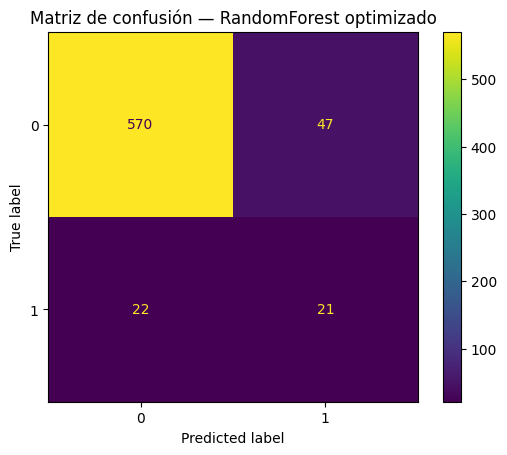

,rank_test_score,mean_test_score,std_test_score,params
2,1,0.327712,0.062151,"{'clf__max_depth': 6, 'clf__min_samples_leaf':..."
3,2,0.327698,0.057486,"{'clf__max_depth': 6, 'clf__min_samples_leaf':..."
7,3,0.326190,0.058418,"{'clf__max_depth': None, 'clf__min_samples_lea..."
6,4,0.318153,0.064045,"{'clf__max_depth': None, 'clf__min_samples_lea..."
1,5,0.294029,0.050851,"{'clf__max_depth': 6, 'clf__min_samples_leaf':..."
0,6,0.275897,0.063958,"{'clf__max_depth': 6, 'clf__min_samples_leaf':..."
5,7,0.169678,0.053154,"{'clf__max_depth': None, 'clf__min_samples_lea..."
4,8,0.156023,0.034241,"{'clf__max_depth': None, 'clf__min_samples_lea..."


In [5]:
# Sección 3: GridSearchCV (prueba todas las combinaciones de params)
df3 = load_csv("dataset_seccion_3_fraude_transaccional.csv")
X, y = split_xy(df3, "target_fraude")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)

pipe = Pipeline(steps=[
    ("prep", build_preprocessor(X_train)),
    ("clf", RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced"))
])

param_grid = {
    "clf__n_estimators": [60, 100],
    "clf__max_depth": [6, None],
    "clf__min_samples_leaf": [2, 5]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(pipe, param_grid=param_grid, scoring="f1", cv=cv, n_jobs=1, verbose=0)
grid.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor F1 CV:", grid.best_score_)
metrics_grid, pred_grid, proba_grid = evaluate_model(grid.best_estimator_, X_test, y_test, "RandomForest optimizado")
pd.DataFrame(grid.cv_results_).sort_values("rank_test_score").head(10)[["rank_test_score","mean_test_score","std_test_score","params"]]

## Sección 4 — RandomizedSearchCV y evaluación final
Dataset: calidad de aire. Se selecciona el mejor modelo y se exportan predicciones.

Mejores hiperparámetros: {'clf__subsample': 0.8, 'clf__n_estimators': 100, 'clf__max_depth': 2, 'clf__learning_rate': 0.15}
Mejor F1 CV: 0.5773281915505929
modelo       GradientBoosting optimizado
accuracy                        0.814583
precision                       0.623188
recall                           0.40566
f1                              0.491429
roc_auc                         0.786349

Reporte de clasificación
              precision    recall  f1-score   support

           0       0.85      0.93      0.89       374
           1       0.62      0.41      0.49       106

    accuracy                           0.81       480
   macro avg       0.73      0.67      0.69       480
weighted avg       0.80      0.81      0.80       480



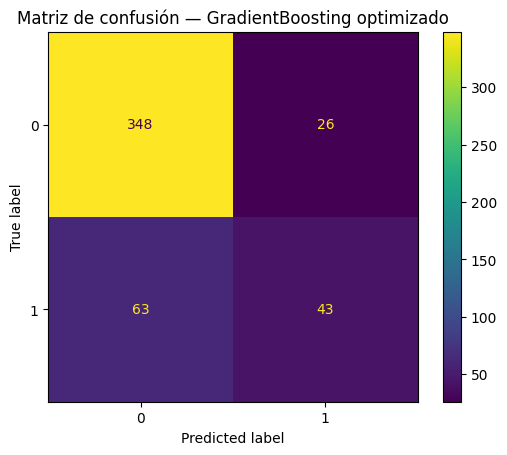

Archivos exportados: laboratorio_8_predicciones_finales.csv y laboratorio_8_metricas_finales.json


,pm25_ug_m3,pm10_ug_m3,no2_ppb,co_ppm,temperatura_c,humedad_pct,viento_m_s,estacion,tipo_dia,y_real,probabilidad_clase_1,prediccion
53,24.14,45.80,36.93,2.38,18.0,36.9,6.08,centro,feriado,0,0.026534,0
1416,33.99,NaN,19.12,0.54,18.8,98.0,3.75,sur,laboral,0,0.021176,0
596,12.74,26.81,44.07,1.88,12.0,85.8,3.87,centro,laboral,0,0.054858,0
718,13.71,29.91,48.35,2.69,15.8,41.1,2.78,norte,laboral,0,0.070853,0
1182,26.95,43.02,42.05,2.53,24.3,90.2,3.15,norte,laboral,0,0.094875,0


In [6]:
# Sección 4: RandomizedSearchCV + evaluación final y export de predicciones
df4 = load_csv("dataset_seccion_4_calidad_aire.csv")
X, y = split_xy(df4, "target_alerta_calidad_aire", drop_id=False)
# Eliminamos fecha_hora para este laboratorio, aunque podría convertirse a variables temporales.
if "fecha_hora" in X.columns:
    X = X.drop(columns=["fecha_hora"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)

pipe = Pipeline(steps=[
    ("prep", build_preprocessor(X_train)),
    ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

param_dist = {
    "clf__n_estimators": [60, 100],
    "clf__learning_rate": [0.05, 0.1, 0.15],
    "clf__max_depth": [2, 3],
    "clf__subsample": [0.8, 1.0]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
random_search = RandomizedSearchCV(
    pipe, param_distributions=param_dist, n_iter=4, scoring="f1", cv=cv,
    random_state=RANDOM_STATE, n_jobs=1, verbose=0
)
random_search.fit(X_train, y_train)

print("Mejores hiperparámetros:", random_search.best_params_)
print("Mejor F1 CV:", random_search.best_score_)
metrics_final, pred_final, proba_final = evaluate_model(random_search.best_estimator_, X_test, y_test, "GradientBoosting optimizado")

predicciones = X_test.copy()
predicciones["y_real"] = y_test.values
predicciones["probabilidad_clase_1"] = proba_final
predicciones["prediccion"] = pred_final
predicciones.to_csv("laboratorio_8_predicciones_finales.csv", index=False)

with open("laboratorio_8_metricas_finales.json", "w") as f:
    json.dump(metrics_final, f, indent=2)

print("Archivos exportados: laboratorio_8_predicciones_finales.csv y laboratorio_8_metricas_finales.json")
predicciones.head()

## Actividad final

1. Compare el modelo base con el modelo optimizado.
2. Explique por qué el test solo se usa al final.
3. Indique qué métrica usaría si la clase positiva es crítica.
4. Adjunte el CSV de predicciones en su entrega.

### Respuestas — Actividad final

1. **Modelo base vs modelo optimizado.** El modelo optimizado (con GridSearch/RandomizedSearch) suele mejorar el F1 y el ROC AUC frente al baseline, porque ajusta hiperparámetros como `n_estimators`, `max_depth` o `learning_rate` mediante validación cruzada en lugar de usar valores por defecto. La mejora puede ser pequeña, pero es más robusta porque se valida con varios folds.

2. **Por qué el test solo se usa al final.** Para obtener una estimación honesta del rendimiento. Todo el ajuste (selección de modelo e hiperparámetros) se hace con train + validación cruzada; si usáramos el test en ese proceso, el modelo se "adaptaría" a él (fuga de información) y las métricas finales serían demasiado optimistas. El test debe simular datos nunca vistos.

3. **Qué métrica usar si la clase positiva es crítica.** El **recall** (y el F1 como balance), porque la clase positiva crítica —fraude, falla, riesgo— es la que no queremos dejar pasar. El recall mide qué porcentaje de esos casos reales detectamos; también es útil el ROC AUC para evaluar la separación global. El accuracy no sirve aquí por el desbalance.

4. **CSV de predicciones.** Se genera automáticamente en la Sección 4 como `laboratorio_8_predicciones_finales.csv` (junto con `laboratorio_8_metricas_finales.json`).
